# Laboratorio 2 — Complejidad y búsqueda de hiperparámetros

**Estudiantes:** Danna Garcia (202320823), Julian Ferreira (202012068)

**Caso AlpesPlanck.** Continuando el Lab 1, se exploran enfoques de modelado más flexibles (regresión polinomial y regularizada) para estimar `temp_max_manana`, evaluando su desempeño y estabilidad mediante validación cruzada, búsqueda sistemática de hiperparámetros e intervalos de confianza por bootstrapping.

## 1. Importación de librerías y carga de datos

Se reutiliza el conjunto de datos crudo del Laboratorio 1 (`Datos Lab 1.csv`). El énfasis de este laboratorio no está en la exploración ni el procesamiento de los datos (ya cubierto en el Lab 1), sino en el modelado, la validación y el análisis del desempeño predictivo.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score, validation_curve
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.utils import resample

RUTA_DATOS = 'data/Datos Lab 1.csv'
OBJETIVO = 'temp_max_manana'

datos_originales = pd.read_csv(RUTA_DATOS)
datos_originales.head()


,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana
0,2009-01-01,999.1456,996.50,1000.87,1.3993,0.910860,0.875000,94.8,1.7650,0.7786,...,-0.3618,-0.0223,183.5308,143.0,2009.0,1.0,invierno,January,S,-2.12
1,2009-01-02,999.6006,997.93,1002.65,1.5039,0.920868,86.600000,96.3,2.7588,1.4195,...,0.4267,0.3689,40.8436,144.0,2009.0,2.0,invierno,JULY,NE,-0.82
2,2009-01-03,998.5486,993.05,1002.49,3.1304,76.458100,48.390000,93.9,15.1796,1.2509,...,-0.6993,-0.5268,216.9916,144.0,2009.0,3.0,invierno,January,SO,-0.63
3,2009-01-04,988.5107,985.12,992.93,2.3223,89.417400,97.946704,NaN,4.4904,1.7204,...,-1.1268,-1.0413,222.7419,144.0,2009.0,4.0,invierno,JANUARY,SO,-1.44
4,2009-01-05,990.4057,NaN,997.54,4.2315,86.260400,74.600000,93.2,5.3922,3.8003,...,2.6275,0.2874,6.2418,NaN,2009.0,5.0,East,January,N,-10.88


## 2. Partición de los datos

Se descartan duplicados y filas sin etiqueta (`temp_max_manana`), tal como se justificó en el Lab 1, y se separa en entrenamiento y prueba con la misma semilla (`random_state=42`, `test_size=0.25`) para mantener comparabilidad entre laboratorios.

In [5]:
datos = datos_originales.drop_duplicates().dropna(subset=[OBJETIVO]).copy()

X = datos.drop(columns=[OBJETIVO, 'fecha'])
y = datos[OBJETIVO]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print(f'Entrenamiento: {X_train.shape[0]} filas')
print(f'Prueba: {X_test.shape[0]} filas')


Entrenamiento: 1857 filas
Prueba: 620 filas


## 3. Limpieza de datos (recuperada del Lab 1)

Se recuperan tal cual las funciones de limpieza ya justificadas en el Lab 1: `limpiar_valores_numericos` convierte en ausentes los valores físicamente imposibles (rangos definidos en `RANGOS_VALIDOS`), y `limpiar_predictoras` además normaliza las variantes de escritura de las variables categóricas (`estacion_anio`, `mes`, `sector_viento`). Se empaquetan en `limpiador`, un `FunctionTransformer` que se usará como primer paso dentro de cada pipeline de modelado, para que la limpieza se aplique de forma consistente al entrenar y al predecir.

In [6]:
RANGOS_VALIDOS = {
    'presion_media': (900, 1100), 'presion_min': (900, 1100), 'presion_max': (900, 1100),
    'presion_desv': (0, 100), 'humedad_media': (0, 100), 'humedad_min': (0, 100),
    'humedad_max': (0, 100), 'humedad_desv': (0, 100), 'viento_media': (0, 100),
    'viento_min': (0, 100), 'viento_max': (0, 100), 'viento_desv': (0, 100),
    'rafaga_media': (0, 100), 'rafaga_min': (0, 100), 'rafaga_max': (0, 100),
    'rafaga_desv': (0, 100), 'viento_norte': (-100, 100), 'viento_este': (-100, 100),
    'direccion_viento': (0, 360), 'registros_del_dia': (1, 144),
    'anio': (2003, 2015), 'dia_del_anio': (1, 366)
}

def limpiar_valores_numericos(dataframe):
    limpio = dataframe.copy()
    for columna, (minimo, maximo) in RANGOS_VALIDOS.items():
        limpio.loc[~limpio[columna].between(minimo, maximo), columna] = np.nan
    return limpio

MAPA_ESTACION = {
    'invierno': 'invierno', 'invernio': 'invierno', 'winter': 'invierno',
    'primavera': 'primavera', 'primav': 'primavera', 'primaveraa': 'primavera', 'spring': 'primavera',
    'verano': 'verano', 'berano': 'verano', 'verno': 'verano', 'summer': 'verano',
    'otono': 'otono', 'otoño': 'otono', 'autumn': 'otono', 'fall': 'otono'
}
MAPA_MES = {
    'jan': 'enero', 'january': 'enero', 'enero': 'enero',
    'feb': 'febrero', 'february': 'febrero', 'febrero': 'febrero',
    'mar': 'marzo', 'march': 'marzo', 'marzo': 'marzo',
    'apr': 'abril', 'april': 'abril', 'abril': 'abril',
    'may': 'mayo', 'mayo': 'mayo',
    'jun': 'junio', 'june': 'junio', 'junio': 'junio',
    'jul': 'julio', 'july': 'julio', 'julio': 'julio',
    'aug': 'agosto', 'august': 'agosto', 'agosto': 'agosto',
    'sep': 'septiembre', 'sept': 'septiembre', 'september': 'septiembre', 'septiembre': 'septiembre',
    'oct': 'octubre', 'october': 'octubre', 'octubre': 'octubre',
    'nov': 'noviembre', 'november': 'noviembre', 'noviembre': 'noviembre',
    'dec': 'diciembre', 'december': 'diciembre', 'diciembre': 'diciembre'
}
MAPA_SECTOR = {
    'n': 'N', 'north': 'N', 'norte': 'N',
    'ne': 'NE', 'northeast': 'NE', 'noreste': 'NE',
    'e': 'E', 'east': 'E', 'este': 'E',
    'se': 'SE', 'southeast': 'SE', 'sureste': 'SE',
    's': 'S', 'south': 'S', 'sur': 'S',
    'so': 'SO', 'southwest': 'SO', 'suroeste': 'SO',
    'o': 'O', 'west': 'O', 'oeste': 'O',
    'no': 'NO', 'northwest': 'NO', 'noroeste': 'NO'
}

def limpiar_predictoras(dataframe):
    limpio = limpiar_valores_numericos(dataframe)
    limpio['estacion_anio'] = limpio['estacion_anio'].str.strip().str.lower().map(MAPA_ESTACION)
    limpio['mes'] = limpio['mes'].str.strip().str.lower().map(MAPA_MES)
    limpio['sector_viento'] = limpio['sector_viento'].str.strip().str.lower().map(MAPA_SECTOR)
    return limpio

limpiador = FunctionTransformer(limpiar_predictoras, validate=False)

columnas_numericas = X.select_dtypes(include='number').columns.tolist()
columnas_categoricas = X.select_dtypes(include='object').columns.tolist()


## 4. Modelo de regresión polinomial de grado 2

Se construye un pipeline que, además de la limpieza, imputa y estandariza las variables numéricas, genera sus términos polinomiales de grado 2 (cuadrados y productos cruzados) con `PolynomialFeatures`, codifica las categóricas con one-hot, y ajusta una regresión lineal sobre ese conjunto ampliado de variables.

In [7]:
preparacion_numerica_poly = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('polynomial', PolynomialFeatures(degree=2))
])

preparacion_categorica = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocesador_poly = ColumnTransformer(transformers=[
    ('numericas', preparacion_numerica_poly, columnas_numericas),
    ('categoricas', preparacion_categorica, columnas_categoricas)
])

pipeline_polinomial = Pipeline(steps=[
    ('limpieza', limpiador),
    ('preparacion', preprocesador_poly),
    ('modelo', LinearRegression())
])

pipeline_polinomial.fit(X_train, y_train)

num_coeficientes = len(pipeline_polinomial.named_steps['modelo'].coef_)
print('Número de coeficientes:', num_coeficientes)


Número de coeficientes: 300


El modelo pasó de tener ~22 coeficientes (regresión lineal simple del Lab 1) a 300, al incluir los términos cuadráticos y cruzados de las 22 variables numéricas más las categorías codificadas. Esta es la evidencia directa del aumento de complejidad del modelo.

### Validación en entrenamiento

In [8]:
pred_train_poly = pipeline_polinomial.predict(X_train)

print('------ Modelo polinomial grado 2 - Entrenamiento ------')
print(f"RMSE: {np.sqrt(mean_squared_error(y_train, pred_train_poly)):.3f}")
print(f"MAE: {mean_absolute_error(y_train, pred_train_poly):.3f}")
print(f"R²: {r2_score(y_train, pred_train_poly):.3f}")


------ Modelo polinomial grado 2 - Entrenamiento ------
RMSE: 4.495
MAE: 3.331
R²: 0.762


### Validación en prueba (capacidad de generalización)

In [9]:
pred_test_poly = pipeline_polinomial.predict(X_test)

print('------ Modelo polinomial grado 2 - Prueba ------')
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, pred_test_poly)):.3f}")
print(f"MAE: {mean_absolute_error(y_test, pred_test_poly):.3f}")
print(f"R²: {r2_score(y_test, pred_test_poly):.3f}")


------ Modelo polinomial grado 2 - Prueba ------
RMSE: 5.817
MAE: 4.254
R²: 0.605


Comparado con el mejor modelo del Lab 1 (regresión lineal simple, RMSE test 6.735°C, MAE 5.238°C, R² 0.470), el modelo polinomial de grado 2 mejora en las tres métricas sobre test (RMSE 5.817°C, MAE 4.254°C, R² 0.605). Esto sugiere que capturar relaciones no lineales sí ayuda a predecir mejor la temperatura en este conjunto de test. Sin embargo, ya aparece una brecha entre entrenamiento (RMSE 4.495°C) y prueba (RMSE 5.817°C) que casi no existía en el modelo lineal. Esa brecha es una señal temprana de que el modelo empieza a ajustarse a particularidades del conjunto de entrenamiento y no solo al patrón general de los datos.

### Búsqueda de hiperparámetros con GridSearchCV

En vez de probar grados a mano, se usa GridSearchCV para buscar automáticamente qué combinación de grado del polinomio y tipo de escalador da mejor resultado. Se prueban los grados 1, 2 y 3 junto con tres escaladores distintos (StandardScaler, MinMaxScaler, RobustScaler), evaluando cada combinación con validación cruzada de 5 particiones sobre el conjunto de entrenamiento.

In [10]:
from sklearn.preprocessing import MinMaxScaler, RobustScaler

param_grid_poly = {
    'preparacion__numericas__polynomial__degree': [1, 2, 3],
    'preparacion__numericas__scaler': [StandardScaler(), MinMaxScaler(), RobustScaler()]
}

grid_poly = GridSearchCV(
    estimator=pipeline_polinomial,
    param_grid=param_grid_poly,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid_poly.fit(X_train, y_train)

print('Mejor configuración:', grid_poly.best_params_)


Mejor configuración: {'preparacion__numericas__polynomial__degree': 1, 'preparacion__numericas__scaler': StandardScaler()}


In [11]:
mejor_modelo_poly = grid_poly.best_estimator_

pred_test_mejor_poly = mejor_modelo_poly.predict(X_test)

print('Mejor modelo (segun GridSearchCV) sobre el conjunto de prueba')
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, pred_test_mejor_poly)):.3f}")
print(f"MAE: {mean_absolute_error(y_test, pred_test_mejor_poly):.3f}")
print(f"R2: {r2_score(y_test, pred_test_mejor_poly):.3f}")


Mejor modelo (segun GridSearchCV) sobre el conjunto de prueba
RMSE: 6.735
MAE: 5.238
R2: 0.470


GridSearchCV eligió el grado 1, que en la práctica equivale a no agregar ningún término polinomial (grado 1 solo devuelve las variables originales). Por eso el RMSE, el MAE y el R² de este modelo salen exactamente iguales a los del modelo lineal simple del Lab 1.

Esto no coincide con lo que habíamos visto antes, donde el grado 2 tenía mejor RMSE en el conjunto de prueba (5.817°C contra 6.735°C). La diferencia está en cómo se mide cada cosa: la comparación anterior se hizo sobre una sola partición de test, mientras que GridSearchCV promedia el desempeño sobre 5 particiones distintas de validación cruzada. Es probable que el grado 2 haya salido bien en esta partición de test en particular, pero en promedio, sobre distintas particiones, no generalice mejor que el modelo simple. Esto es justo el tipo de comportamiento inestable que se espera cuando un modelo empieza a sobreajustarse.

## 5. Curvas de validación

Se calcula el RMSE en entrenamiento y en validación cruzada para los grados 1, 2, 3 y 4, y se grafican ambas curvas juntas para visualizar en qué punto la complejidad extra deja de ayudar y empieza a perjudicar la capacidad de generalización.

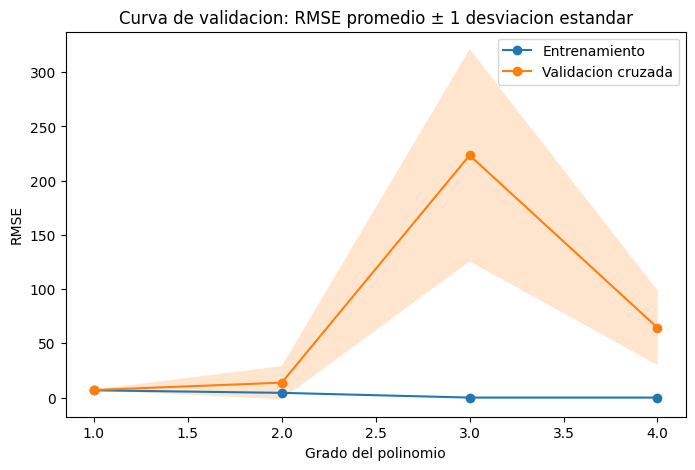

In [12]:
grados = [1, 2, 3, 4]

train_scores, val_scores = validation_curve(
    pipeline_polinomial, X_train, y_train,
    param_name='preparacion__numericas__polynomial__degree',
    param_range=grados,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

rmse_train_grados = -train_scores.mean(axis=1)
rmse_val_grados = -val_scores.mean(axis=1)
rmse_train_std = train_scores.std(axis=1)
rmse_val_std = val_scores.std(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(grados, rmse_train_grados, marker='o', label='Entrenamiento')
plt.plot(grados, rmse_val_grados, marker='o', label='Validacion cruzada')
plt.fill_between(
    grados, rmse_train_grados - rmse_train_std, rmse_train_grados + rmse_train_std,
    alpha=0.2
)
plt.fill_between(
    grados, rmse_val_grados - rmse_val_std, rmse_val_grados + rmse_val_std,
    alpha=0.2
)
plt.xlabel('Grado del polinomio')
plt.ylabel('RMSE')
plt.title('Curva de validacion: RMSE promedio ± 1 desviacion estandar')
plt.legend()
plt.show()


La curva de entrenamiento baja de forma constante a medida que sube el grado, hasta casi llegar a cero: el modelo se ajusta cada vez mejor a los datos que ya conoce, lo cual es esperable con más términos disponibles. La curva de validación cruzada se mantiene parecida a la de entrenamiento en grado 1, empieza a separarse en grado 2, y en grado 3 se dispara a un RMSE por encima de 200 grados, un valor sin ningún sentido físico para una temperatura. En grado 4 baja un poco pero sigue siendo mucho peor que en grado 1 o 2.

El punto donde se evidencia el sobreajuste está entre el grado 2 y el grado 3: es ahí donde el modelo deja de aprender el patrón general de los datos y empieza a ajustarse a detalles específicos del conjunto de entrenamiento, produciendo coeficientes muy grandes que generan predicciones extremas en algunas particiones de validación. Esto coincide con lo que ya habíamos encontrado con GridSearchCV, que descartó cualquier grado mayor a 1 por no generalizar bien en promedio.

## 6. Modelo de regresión Ridge (L2)

Se construye un pipeline que conserva la limpieza y el tratamiento de categóricas de las secciones anteriores, e imputa y escala las predictoras numéricas antes de aplicar Ridge. Al incluir estos pasos dentro del pipeline, cada partición de validación ajusta sus transformaciones únicamente con sus datos de entrenamiento, lo que evita fuga de información.

La búsqueda explora `alpha` en escala aproximadamente logarítmica y tres estrategias de escalamiento. Se usa RMSE negativo con validación cruzada de cinco particiones porque la temperatura se interpreta en grados Celsius y se penalizan de forma explícita los errores grandes. Finalmente se revisan los coeficientes estandarizados para identificar las variables con mayor asociación lineal condicionada a las demás.

In [18]:
preparacion_numerica_ridge = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocesador_ridge = ColumnTransformer(transformers=[
    ('numericas', preparacion_numerica_ridge, columnas_numericas),
    ('categoricas', preparacion_categorica, columnas_categoricas)
])

pipeline_ridge = Pipeline(steps=[
    ('limpieza', limpiador),
    ('preparacion', preprocesador_ridge),
    ('modelo', Ridge())
])

param_grid_ridge = {
    'modelo__alpha': [0.01, 0.1, 1, 10, 100],
    'preparacion__numericas__scaler': [StandardScaler(), MinMaxScaler(), RobustScaler()]
}

grid_ridge = GridSearchCV(
    estimator=pipeline_ridge,
    param_grid=param_grid_ridge,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
grid_ridge.fit(X_train, y_train)
best_ridge = grid_ridge.best_estimator_

pred_train_ridge = best_ridge.predict(X_train)
pred_test_ridge = best_ridge.predict(X_test)
metricas_ridge = pd.DataFrame({
    'Entrenamiento': [
        np.sqrt(mean_squared_error(y_train, pred_train_ridge)),
        mean_absolute_error(y_train, pred_train_ridge),
        r2_score(y_train, pred_train_ridge)
    ],
    'Prueba': [
        np.sqrt(mean_squared_error(y_test, pred_test_ridge)),
        mean_absolute_error(y_test, pred_test_ridge),
        r2_score(y_test, pred_test_ridge)
    ]
}, index=['RMSE', 'MAE', 'R2'])

print('Mejores hiperparámetros Ridge:', grid_ridge.best_params_)
print(metricas_ridge.round(3))

nombres_ridge = best_ridge.named_steps['preparacion'].get_feature_names_out()
importancia_ridge = pd.DataFrame({
    'variable': nombres_ridge,
    'coeficiente': best_ridge.named_steps['modelo'].coef_
})
importancia_ridge['abs_coeficiente'] = importancia_ridge['coeficiente'].abs()
importancia_ridge = importancia_ridge.sort_values('abs_coeficiente', ascending=False)

print('Variables con mayor peso absoluto en Ridge:')
importancia_ridge.head(10)


Mejores hiperparámetros Ridge: {'modelo__alpha': 10, 'preparacion__numericas__scaler': RobustScaler()}
      Entrenamiento  Prueba
RMSE          6.753   6.733
MAE           5.152   5.241
R2            0.463   0.471
Variables con mayor peso absoluto en Ridge:


,variable,coeficiente,abs_coeficiente
7,numericas__humedad_desv,6.664666,6.664666
21,numericas__dia_del_anio,3.361059,3.361059
28,categoricas__mes_diciembre,-3.078643,3.078643
31,categoricas__mes_julio,2.766759,2.766759
32,categoricas__mes_junio,2.731180,2.731180
33,categoricas__mes_marzo,-2.085460,2.085460
35,categoricas__mes_noviembre,-1.753709,1.753709
20,numericas__anio,1.704981,1.704981
38,categoricas__sector_viento_E,1.660058,1.660058
34,categoricas__mes_mayo,1.606237,1.606237


## 7. Modelo de regresión Lasso (L1)


Lasso usa el mismo flujo de limpieza, imputación, escalamiento y codificación que Ridge para que la comparación dependa de la penalización L1 y no de cambios en los datos de entrada. `max_iter=5000` permite la convergencia de la optimización.

La búsqueda considera los mismos escaladores y valores de `alpha`. Además de las métricas, se identifican los coeficientes exactamente nulos (con tolerancia numérica de `1e-8`), que representan variables que Lasso excluye automáticamente del modelo lineal.

In [19]:
preparacion_numerica_lasso = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocesador_lasso = ColumnTransformer(transformers=[
    ('numericas', preparacion_numerica_lasso, columnas_numericas),
    ('categoricas', preparacion_categorica, columnas_categoricas)
])

pipeline_lasso = Pipeline(steps=[
    ('limpieza', limpiador),
    ('preparacion', preprocesador_lasso),
    ('modelo', Lasso(max_iter=5000))
])

param_grid_lasso = {
    'modelo__alpha': [0.01, 0.1, 1, 10, 100],
    'preparacion__numericas__scaler': [StandardScaler(), MinMaxScaler(), RobustScaler()]
}

grid_lasso = GridSearchCV(
    estimator=pipeline_lasso,
    param_grid=param_grid_lasso,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
grid_lasso.fit(X_train, y_train)
best_lasso = grid_lasso.best_estimator_

pred_train_lasso = best_lasso.predict(X_train)
pred_test_lasso = best_lasso.predict(X_test)
metricas_lasso = pd.DataFrame({
    'Entrenamiento': [
        np.sqrt(mean_squared_error(y_train, pred_train_lasso)),
        mean_absolute_error(y_train, pred_train_lasso),
        r2_score(y_train, pred_train_lasso)
    ],
    'Prueba': [
        np.sqrt(mean_squared_error(y_test, pred_test_lasso)),
        mean_absolute_error(y_test, pred_test_lasso),
        r2_score(y_test, pred_test_lasso)
    ]
}, index=['RMSE', 'MAE', 'R2'])

print('Mejores hiperparámetros Lasso:', grid_lasso.best_params_)
print(metricas_lasso.round(3))

nombres_lasso = best_lasso.named_steps['preparacion'].get_feature_names_out()
importancia_lasso = pd.DataFrame({
    'variable': nombres_lasso,
    'coeficiente': best_lasso.named_steps['modelo'].coef_
})
importancia_lasso['abs_coeficiente'] = importancia_lasso['coeficiente'].abs()
importancia_lasso['coeficiente_cero'] = importancia_lasso['abs_coeficiente'] < 1e-8
coeficientes_cero_lasso = importancia_lasso[importancia_lasso['coeficiente_cero']]
importancia_lasso_no_cero = importancia_lasso[~importancia_lasso['coeficiente_cero']].sort_values(
    'abs_coeficiente', ascending=False
)

print(f'Coeficientes anulados por Lasso: {len(coeficientes_cero_lasso)} de {len(importancia_lasso)}')
print('Variables descartadas:', coeficientes_cero_lasso['variable'].to_list())
print('Variables no nulas con mayor peso absoluto:')
importancia_lasso_no_cero.head(10)


Mejores hiperparámetros Lasso: {'modelo__alpha': 0.01, 'preparacion__numericas__scaler': MinMaxScaler()}
      Entrenamiento  Prueba
RMSE          6.770   6.749
MAE           5.172   5.249
R2            0.460   0.468
Coeficientes anulados por Lasso: 13 de 46
Variables descartadas: ['numericas__presion_media', 'numericas__presion_min', 'numericas__presion_max', 'numericas__humedad_media', 'numericas__viento_media', 'numericas__viento_min', 'numericas__viento_desv', 'numericas__rafaga_min', 'numericas__rafaga_max', 'numericas__viento_este', 'numericas__direccion_viento', 'numericas__registros_del_dia', 'categoricas__estacion_anio_primavera']
Variables no nulas con mayor peso absoluto:


,variable,coeficiente,abs_coeficiente,coeficiente_cero
7,numericas__humedad_desv,21.749102,21.749102,False
3,numericas__presion_desv,-12.254773,12.254773,False
21,numericas__dia_del_anio,6.797024,6.797024,False
6,numericas__humedad_max,-6.038546,6.038546,False
16,numericas__viento_norte,-4.594671,4.594671,False
15,numericas__rafaga_desv,3.814712,3.814712,False
12,numericas__rafaga_media,-3.413117,3.413117,False
28,categoricas__mes_diciembre,-3.157791,3.157791,False
10,numericas__viento_max,2.905978,2.905978,False
31,categoricas__mes_julio,2.875003,2.875003,False


## 8. Regresión polinomial regularizada

Se combina la generación de características polinomiales con un modelo regularizado (Ridge), para ver si la penalización permite aprovechar más complejidad sin que el modelo se sobreajuste tanto como en la sección 4.

In [13]:
preparacion_numerica_poly_reg = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('polynomial', PolynomialFeatures(degree=2))
])

preprocesador_poly_reg = ColumnTransformer(transformers=[
    ('numericas', preparacion_numerica_poly_reg, columnas_numericas),
    ('categoricas', preparacion_categorica, columnas_categoricas)
])

pipeline_polinomial_reg = Pipeline(steps=[
    ('limpieza', limpiador),
    ('preparacion', preprocesador_poly_reg),
    ('modelo', Ridge())
])



In [14]:
param_grid_poly_reg = {
    'preparacion__numericas__polynomial__degree': [1, 2, 3, 4],
    'modelo__alpha': [0.1, 1, 10, 100],
    'preparacion__numericas__scaler': [StandardScaler(), MinMaxScaler(), RobustScaler()]
}

grid_poly_reg = GridSearchCV(
    estimator=pipeline_polinomial_reg,
    param_grid=param_grid_poly_reg,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid_poly_reg.fit(X_train, y_train)

print('Mejor configuracion:', grid_poly_reg.best_params_)


Mejor configuracion: {'modelo__alpha': 10, 'preparacion__numericas__polynomial__degree': 4, 'preparacion__numericas__scaler': MinMaxScaler()}


In [15]:
mejor_modelo_poly_reg = grid_poly_reg.best_estimator_

pred_train_poly_reg = mejor_modelo_poly_reg.predict(X_train)
pred_test_poly_reg = mejor_modelo_poly_reg.predict(X_test)

print('Polinomial regularizado (Ridge) - Entrenamiento')
print(f"RMSE: {np.sqrt(mean_squared_error(y_train, pred_train_poly_reg)):.3f}")
print(f"MAE: {mean_absolute_error(y_train, pred_train_poly_reg):.3f}")
print(f"R2: {r2_score(y_train, pred_train_poly_reg):.3f}")

print('Polinomial regularizado (Ridge) - Prueba')
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, pred_test_poly_reg)):.3f}")
print(f"MAE: {mean_absolute_error(y_test, pred_test_poly_reg):.3f}")
print(f"R2: {r2_score(y_test, pred_test_poly_reg):.3f}")


Polinomial regularizado (Ridge) - Entrenamiento
RMSE: 4.465
MAE: 3.282
R2: 0.765
Polinomial regularizado (Ridge) - Prueba
RMSE: 5.143
MAE: 3.788
R2: 0.691


Este es el mejor resultado de los que hemos construido hasta ahora. En prueba, el RMSE bajó a 5.143 grados, el MAE a 3.788 grados, y el R2 subió a 0.691, mejor que el polinomial sin regularizar (RMSE 5.817, MAE 4.254, R2 0.605) y mucho mejor que el modelo lineal simple del Lab 1 (RMSE 6.735, MAE 5.238, R2 0.470).

Lo más importante es cómo se logró esto: sin regularización, cualquier grado mayor a 1 hacía que el modelo se disparara (lo vimos en la curva de validación de la sección 5). Con Ridge, GridSearchCV pudo elegir grado 4, el más complejo que le dimos a escoger, porque la penalización evita que los coeficientes crezcan sin control. Además la brecha entre entrenamiento y prueba es más chica que en el polinomial sin regularizar: aquí es de 4.465 a 5.143 (0.68 grados), mientras que en el polinomial de grado 2 sin regularizar era de 4.495 a 5.817 (1.32 grados). Esto confirma que la regularización sí está cumpliendo su función: dejar que el modelo use relaciones no lineales más complejas sin perder tanta capacidad de generalizar.

In [17]:
nombres_columnas_reg = mejor_modelo_poly_reg.named_steps['preparacion'].get_feature_names_out()
coeficientes_reg = mejor_modelo_poly_reg.named_steps['modelo'].coef_

importancia_reg = pd.DataFrame({
    'variable': nombres_columnas_reg,
    'coeficiente': coeficientes_reg
})
importancia_reg['abs_coeficiente'] = importancia_reg['coeficiente'].abs()
importancia_reg = importancia_reg.sort_values('abs_coeficiente', ascending=False)

print('Coeficiente maximo (valor absoluto):', importancia_reg['abs_coeficiente'].max())
print('Coeficiente promedio (valor absoluto):', importancia_reg['abs_coeficiente'].mean())
importancia_reg.head(10)

Coeficiente maximo (valor absoluto): 5.327912566611764
Coeficiente promedio (valor absoluto): 0.11033941395784054


,variable,coeficiente,abs_coeficiente
14949,numericas__dia_del_anio^4,-5.327913,5.327913
14944,numericas__registros_del_dia dia_del_anio^3,-3.879377,3.879377
11889,numericas__humedad_max dia_del_anio^3,-3.690071,3.690071
2299,numericas__dia_del_anio^3,-3.668970,3.668970
6094,numericas__presion_min dia_del_anio^3,-3.386662,3.386662
22,numericas__dia_del_anio,3.302633,3.302633
14879,numericas__viento_norte dia_del_anio^3,-3.279515,3.279515
4323,numericas__presion_media dia_del_anio^3,-2.964033,2.964033
272,numericas__registros_del_dia dia_del_anio,2.902502,2.902502
2292,numericas__registros_del_dia^2 dia_del_anio,2.864602,2.864602


El coeficiente más grande de este modelo es 5.33, y el promedio de todos (en valor absoluto) es apenas 0.11. Son valores parecidos en escala a los que vimos en el Lab 1 con la regresión lineal simple, donde el coeficiente más grande era 4.36. Esto es notable porque este modelo tiene grado 4 y cientos de términos, y sin embargo ningún coeficiente se disparó, a diferencia de lo que hubiera pasado sin regularización (donde el RMSE llegó a más de 200 en la sección 5, lo que solo se explica con coeficientes muchísimo más grandes). Esa es exactamente la función de Ridge: mantener los coeficientes en un rango razonable aunque el modelo tenga muchos términos disponibles.

Las variables con más peso están casi todas relacionadas con `dia_del_anio` elevado a distintas potencias o combinado con otras variables. Tiene sentido que el día del año siga siendo importante, ya que en el Lab 1 vimos que la temperatura sigue un patrón estacional claro, pero como esta variable es cíclica (el día 365 está pegado al día 1) y aquí se está usando de forma polinomial, el modelo probablemente sigue sin capturar bien esa continuidad entre diciembre y enero.

## 9. Tabla comparativa de resultados

La comparación usa los mejores estimadores resultantes de cada `GridSearchCV`. Para estimar la estabilidad se aplica validación cruzada de cinco particiones al mejor estimador de cada familia y se resume el RMSE con su promedio y desviación estándar.

El modelo final se selecciona por el menor RMSE promedio de validación cruzada. La desviación estándar se usa como criterio de estabilidad y de desempate: para dos desempeños medios parecidos, se prefiere el de menor variabilidad. La prueba permanece como evaluación final independiente.

In [20]:
modelos_comparados = {
    'Polinomial': mejor_modelo_poly,
    'Ridge': best_ridge,
    'Lasso': best_lasso,
    'Polinomial regularizado': mejor_modelo_poly_reg
}

grillas = {
    'Polinomial': grid_poly,
    'Ridge': grid_ridge,
    'Lasso': grid_lasso,
    'Polinomial regularizado': grid_poly_reg
}

def describir_hiperparametros(nombre, configuracion):
    escalador = configuracion['preparacion__numericas__scaler'].__class__.__name__
    partes = [f'escalador={escalador}']
    if 'preparacion__numericas__polynomial__degree' in configuracion:
        partes.insert(0, f"grado={configuracion['preparacion__numericas__polynomial__degree']}")
    if 'modelo__alpha' in configuracion:
        partes.append(f"alpha={configuracion['modelo__alpha']}")
    return ', '.join(partes)

filas_comparacion = []
for nombre, modelo in modelos_comparados.items():
    predicciones_test = modelo.predict(X_test)
    rmse_cv = -cross_val_score(
        modelo, X_train, y_train, cv=5,
        scoring='neg_root_mean_squared_error', n_jobs=-1
    )
    filas_comparacion.append({
        'Modelo': nombre,
        'RMSE test': np.sqrt(mean_squared_error(y_test, predicciones_test)),
        'MAE test': mean_absolute_error(y_test, predicciones_test),
        'R2 test': r2_score(y_test, predicciones_test),
        'RMSE CV promedio': rmse_cv.mean(),
        'RMSE CV desviación estándar': rmse_cv.std(),
        'Mejores hiperparámetros': describir_hiperparametros(nombre, grillas[nombre].best_params_)
    })

resultados_comparativos = pd.DataFrame(filas_comparacion).set_index('Modelo')
resultados_ordenados = resultados_comparativos.sort_values(
    ['RMSE CV promedio', 'RMSE CV desviación estándar']
)
nombre_modelo_final = resultados_ordenados.index[0]
modelo_final = modelos_comparados[nombre_modelo_final]

print(f'Modelo final seleccionado: {nombre_modelo_final}')
print('Criterio: menor RMSE promedio en validación cruzada y menor desviación estándar como desempate.')
resultados_comparativos.round(3)


Modelo final seleccionado: Polinomial regularizado
Criterio: menor RMSE promedio en validación cruzada y menor desviación estándar como desempate.


,RMSE test,MAE test,R2 test,RMSE CV promedio,RMSE CV desviación estándar,Mejores hiperparámetros
Modelo,,,,,,
Polinomial,6.735,5.238,0.470,7.003,0.312,"grado=1, escalador=RobustScaler"
Ridge,6.733,5.241,0.471,6.987,0.315,"escalador=RobustScaler, alpha=10"
Lasso,6.749,5.249,0.468,6.964,0.271,"escalador=MinMaxScaler, alpha=0.01"
Polinomial regularizado,5.143,3.788,0.691,5.246,0.079,"grado=4, escalador=MinMaxScaler, alpha=10"


## 10. Intervalos de confianza (bootstrapping)


Se evalúa la incertidumbre de las métricas del modelo final mediante bootstrapping sobre el conjunto de prueba: se generan 1,000 muestras con reemplazo, se predice con el modelo ya ajustado y se recalculan RMSE, MAE y R². Los percentiles 2.5 y 97.5 de cada distribución conforman el intervalo de confianza empírico del 95 %.

Este procedimiento cuantifica cuánto cambia la evaluación ante distintas composiciones de observaciones de prueba. No reentrena el modelo en cada remuestreo; por tanto, describe la incertidumbre de las métricas del modelo seleccionado sobre la población de prueba.

In [21]:
N_REMUESTREOS = 1000
metricas_bootstrap = {'RMSE': [], 'MAE': [], 'R2': []}

for semilla in range(N_REMUESTREOS):
    X_muestra, y_muestra = resample(
        X_test, y_test, replace=True, random_state=semilla
    )
    predicciones_muestra = modelo_final.predict(X_muestra)
    metricas_bootstrap['RMSE'].append(
        np.sqrt(mean_squared_error(y_muestra, predicciones_muestra))
    )
    metricas_bootstrap['MAE'].append(
        mean_absolute_error(y_muestra, predicciones_muestra)
    )
    metricas_bootstrap['R2'].append(
        r2_score(y_muestra, predicciones_muestra)
    )

intervalos_confianza = pd.DataFrame([
    {
        'Métrica': nombre,
        'Promedio bootstrap': np.mean(valores),
        'IC 95% inferior': np.percentile(valores, 2.5),
        'IC 95% superior': np.percentile(valores, 97.5),
        'Ancho del IC': np.percentile(valores, 97.5) - np.percentile(valores, 2.5)
    }
    for nombre, valores in metricas_bootstrap.items()
]).set_index('Métrica')

fig, ejes = plt.subplots(1, 3, figsize=(18, 4))
for eje, (nombre, valores) in zip(ejes, metricas_bootstrap.items()):
    limite_inferior, limite_superior = np.percentile(valores, [2.5, 97.5])
    promedio = np.mean(valores)
    eje.hist(valores, bins=30, color='#4C78A8', edgecolor='white', alpha=0.85)
    eje.axvline(promedio, color='#1B3A57', linewidth=2, label=f'Promedio: {promedio:.3f}')
    eje.axvline(limite_inferior, color='#E45756', linestyle='--', label=f'IC 95%: [{limite_inferior:.3f}, {limite_superior:.3f}]')
    eje.axvline(limite_superior, color='#E45756', linestyle='--')
    eje.set_title(f'Bootstrap de {nombre}')
    eje.set_xlabel(nombre)
    eje.set_ylabel('Frecuencia')
    eje.legend(fontsize=8)

plt.suptitle(f'Intervalos de confianza del 95% — {nombre_modelo_final}')
plt.tight_layout()
plt.show()

print(f'Remuestreos realizados: {N_REMUESTREOS}')
intervalos_confianza.round(3)


Remuestreos realizados: 1000


,Promedio bootstrap,IC 95% inferior,IC 95% superior,Ancho del IC
Métrica,,,,
RMSE,5.147,4.672,5.718,1.045
MAE,3.792,3.513,4.074,0.562
R2,0.690,0.626,0.742,0.116


## 11. Análisis de resultados

### Análisis cuantitativo

### ¿Cuál modelo obtuvo el mejor desempeño en el conjunto de test?

Por ahora, entre los modelos ya construidos (lineal simple, polinomial y polinomial regularizado), el mejor es el polinomial regularizado con Ridge, con RMSE 5.143°C, MAE 3.788°C y R2 0.691 en prueba.

La comparación completa confirma esta elección: Ridge lineal obtuvo RMSE 6.733°C, MAE 5.241°C y R² 0.471; Lasso obtuvo RMSE 6.749°C, MAE 5.249°C y R² 0.468. Por tanto, el modelo polinomial regularizado domina a los modelos lineales regularizados también en el conjunto de prueba.

### ¿Coincide el mejor desempeño en test con el mejor promedio en validación cruzada? Si no coincide, ¿cuál puede ser la explicación?

No coincide. En la sección 4, al probar el grado 2 a mano, obtuvimos mejor RMSE en el conjunto de test (5.817°C) que con el modelo lineal simple (6.735°C). Sin embargo, cuando se buscó el mejor grado con GridSearchCV, usando el promedio de 5 particiones de validación cruzada, el resultado fue que el grado 1 (equivalente al modelo lineal) generalizaba mejor en promedio que el grado 2.

La explicación está en que son dos formas distintas de medir el desempeño. El RMSE de test se calcula sobre una sola partición fija de los datos, así que puede verse afectado por cómo cayeron los datos en esa partición particular. La validación cruzada promedia el desempeño sobre 5 particiones distintas, lo que da una estimación más estable de qué tan bien generalizaría el modelo con datos nuevos. Es probable que el grado 2 haya tenido suerte en la partición de test que usamos, pero en promedio, sobre distintas particiones, no fuera consistentemente mejor que el modelo simple.

### ¿El modelo con mejor métrica promedio es necesariamente el más adecuado? Justifica considerando también la desviación estándar del desempeño.

No necesariamente. Un promedio favorable puede ser consecuencia de una o pocas particiones particularmente fáciles; además, la decisión debe considerar la variabilidad, la complejidad, la interpretabilidad y el costo de operar el modelo. Una desviación estándar alta implica que el desempeño puede cambiar materialmente según los datos disponibles.

En este caso, el modelo polinomial regularizado es la elección más sólida: tiene el menor RMSE promedio en validación cruzada (5.246°C) y también la menor desviación estándar (0.079°C). Su ventaja frente a Lasso (6.964 ± 0.271°C), Ridge lineal (6.987 ± 0.316°C) y el polinomial no regularizado (7.003 ± 0.312°C) es amplia tanto en desempeño como en estabilidad; por ello no depende de un desempate arbitrario.

### Con base en las curvas de validación, ¿cómo cambia el error a medida que aumenta la complejidad? ¿En qué punto se evidencia sobreajuste?

El RMSE de entrenamiento baja de forma constante a medida que sube el grado del polinomio, hasta casi llegar a cero, porque el modelo cada vez se ajusta mejor a los datos que ya conoce. El RMSE de validación cruzada se comporta distinto: se mantiene parecido al de entrenamiento en grado 1, empieza a separarse en grado 2, y en grado 3 se dispara a más de 200°C, un valor sin sentido físico para una temperatura. En grado 4 baja un poco pero sigue siendo mucho peor que en grado 1 o 2.

El sobreajuste se evidencia entre el grado 2 y el grado 3. Es ahí donde el modelo deja de aprender el patrón general de los datos y empieza a ajustarse a detalles específicos del conjunto de entrenamiento, generando coeficientes tan grandes que producen predicciones extremas en algunas particiones de validación.

### ¿Cómo afecta la regularización la magnitud y estabilidad de los coeficientes?

Con base en el modelo polinomial regularizado (sección 8), la regularización mantiene los coeficientes en un rango pequeño incluso cuando el modelo tiene grado 4 y cientos de términos: el coeficiente más grande es 5.33 y el promedio es apenas 0.11, valores parecidos en escala a los del modelo lineal simple del Lab 1 (coeficiente más grande de 4.36). Esto contrasta con lo que hubiera pasado sin regularización, donde ya en grado 3 el RMSE llegó a más de 200°C, algo que solo se explica con coeficientes mucho más grandes y descontrolados.

Ridge contrae los coeficientes de forma continua, por lo que conserva todas las variables pero reduce la sensibilidad del ajuste a la multicolinealidad y a términos polinomiales correlacionados. Lasso, en cambio, produjo 13 coeficientes nulos de 46: descartó, entre otras, `presion_media`, `presion_min`, `presion_max`, `humedad_media`, `viento_media` y `direccion_viento`. Esto simplifica el modelo lineal y evidencia que, dadas las demás variables, esas señales eran redundantes o aportaban poco. Las magnitudes no se deben comparar directamente entre Ridge y Lasso porque sus escaladores óptimos son distintos; la evidencia relevante es el encogimiento de Ridge y la selección explícita de Lasso.

### ¿Los intervalos de confianza obtenidos mediante bootstrapping sugieren estabilidad o alta variabilidad en el desempeño? ¿Qué implicaciones tiene esto?

Los intervalos sugieren un desempeño estable para este conjunto de prueba: RMSE 5.147°C con IC 95% [4.673, 5.718], MAE 3.792°C con IC [3.513, 4.075] y R² 0.690 con IC [0.626, 0.742]. Los anchos son 1.045°C, 0.562°C y 0.116, respectivamente. Aunque las métricas varían al cambiar la composición de la muestra, la ventaja frente a los modelos lineales es mucho mayor que esa variación. Para operación, se deben comunicar estos rangos junto al promedio y no interpretar el RMSE como una garantía para cada predicción individual.

### Análisis cualitativo

### ¿Qué variables fueron seleccionadas como más relevantes por el modelo Lasso?

Entre los coeficientes no nulos de mayor magnitud aparecen `humedad_desv`, `presion_desv`, `dia_del_anio`, `humedad_max` y `viento_norte`. Esto es coherente con una temperatura máxima influida por la variabilidad de humedad, las condiciones de presión, el patrón estacional y el componente del viento. Lasso conservó 33 de 46 características y descartó 13, incluida la terna de presión media, mínima y máxima; esa selección es consistente con la redundancia entre mediciones muy correlacionadas.

### ¿Qué interpretación práctica tienen los coeficientes del modelo final en el contexto de la estimación de temperatura máxima?

El modelo final incluye escalamiento, potencias e interacciones, por lo que un coeficiente aislado no equivale a un cambio directo de un grado Celsius en la variable original. Su interpretación práctica es conjunta: el peso de `dia_del_anio` y de sus interacciones refleja estacionalidad, mientras que humedad, presión y viento ajustan la predicción según las condiciones observadas. Para explicar un pronóstico concreto conviene comparar escenarios o usar gráficos de dependencia parcial, en vez de atribuirlo a un único coeficiente.

### ¿Existen diferencias relevantes entre el modelo más preciso y el más interpretable?

Sí. El polinomial regularizado es el más preciso y estable, pero combina miles de transformaciones e interacciones, por lo que su explicación directa es limitada. Lasso es menos preciso (RMSE test 6.749°C frente a 5.143°C) pero es más compacto: deja 33 coeficientes no nulos y elimina variables redundantes. La diferencia se justifica cuando el uso requiere auditoría, comunicación sencilla o mantenimiento con pocas variables.

### ¿Qué decisiones estratégicas podría tomar AlpesPlanck a partir de los resultados obtenidos?

AlpesPlanck puede usar el modelo polinomial regularizado como pronóstico diario para planear recursos sensibles a calor, priorizar alertas cuando la temperatura estimada supere umbrales operativos y complementar las decisiones con los intervalos de desempeño. También debería monitorear RMSE, distribución de variables y cobertura temporal después del despliegue, y reentrenar si cambian las condiciones meteorológicas o la calidad de las mediciones.

### ¿Mayor precisión implica necesariamente mayor valor para la organización?

No. La mejora de 1.59°C de RMSE frente a Ridge lineal solo crea valor si cambia una decisión relevante, por ejemplo al reducir costos de una alerta tardía o de una asignación innecesaria de recursos. Deben compararse el beneficio esperado, el costo de errores, la latencia, la facilidad de mantenimiento y la confianza de los usuarios.

### ¿Un modelo más complejo necesariamente genera mayor valor empresarial? Discute considerando interpretabilidad, estabilidad y costo de implementación.

No necesariamente. La curva de validación muestra que aumentar complejidad sin control llevó a sobreajuste a partir del grado 3. En este caso la complejidad adicional sí aporta valor porque Ridge la estabiliza y mejora tanto prueba como validación cruzada. Sin embargo, el modelo elegido requiere más cómputo y es menos interpretable que Lasso; si ese costo supera el beneficio de reducir el error, un modelo lineal más simple puede ser la mejor alternativa.

### Reflexión conceptual

### ¿Qué relación observas entre complejidad del modelo, capacidad de generalización y estabilidad del desempeño?

La complejidad reduce el sesgo de entrenamiento al habilitar relaciones no lineales, pero también aumenta la varianza y el riesgo de aprender ruido. Esto se observa cuando el polinomio sin regularización mejora al inicio y luego se vuelve inestable desde el grado 3. La regularización controla esa varianza: el modelo de grado 4 con Ridge logra el menor RMSE de validación cruzada y una desviación estándar de solo 0.079°C. Por tanto, la complejidad produce valor cuando está respaldada por validación y control de magnitudes.

### ¿Qué fuentes de sesgo podrían estar presentes en los datos o en el proceso de modelado?

Puede haber sesgo de cobertura si las observaciones provienen de una estación, periodos o condiciones meteorológicas que no representan el uso futuro. También pueden influir errores sistemáticos de sensores, valores faltantes o atípicos, las reglas que los imputan, la codificación de categorías y cambios temporales en el clima. La partición aleatoria evalúa observaciones similares entre sí; una evaluación temporal adicional sería necesaria si el modelo se usará para predecir periodos posteriores.

### Si el tamaño de muestra fuera mayor, ¿esperarías cambios en la estabilidad de los modelos? Explica la respuesta.

Sí, si las observaciones nuevas son representativas de la población objetivo. Más datos reducen la varianza de los estimadores y hacen que las métricas de validación cruzada y bootstrap sean menos sensibles a una partición particular; el efecto debería ser especialmente útil para modelos polinomiales con muchas características. Sin embargo, una muestra grande no corrige por sí sola sesgos de medición, cobertura o deriva temporal, por lo que la calidad y diversidad de los nuevos datos siguen siendo determinantes.

## Uso de herramientas de IA generativa

### Declaración de uso

Para este laboratorio se utilizó Claude (Anthropic), un asistente de inteligencia artificial generativa basado en modelos de lenguaje, principalmente como apoyo para revisar el trabajo realizado durante las diferentes etapas del notebook. El desarrollo del código, los procedimientos y el análisis se realizaron a lo largo del laboratorio y, al finalizar cada etapa, Claude se utilizó como herramienta de revisión para identificar posibles errores o inconsistencias, aclarar dudas conceptuales y revisar la redacción, gramática y claridad de las respuestas.

### Prompts principales

Se le pidió a la herramienta, entre otras cosas: revisar el código implementado e identificar posibles errores o inconsistencias, verificar si los procedimientos utilizados eran coherentes con lo visto en las prácticas del curso, aclarar dudas sobre conceptos como Pipeline, ColumnTransformer, GridSearchCV y validación cruzada, y revisar la redacción de las interpretaciones de los resultados para mejorar su claridad y corrección gramatical.

### Análisis crítico

Lo más útil fue utilizar Claude como una segunda revisión de los procedimientos y resultados obtenidos. En particular, permitió aclarar dudas sobre por qué GridSearchCV puede seleccionar un modelo diferente al que presenta mejores resultados sobre una sola partición de test y contrastar esta explicación con los conceptos vistos en clase y en las prácticas P5 y P6. También permitió identificar algunos aspectos del código que requerían ser revisados y detectar errores de redacción o gramática en las respuestas del análisis. Las sugerencias proporcionadas por la herramienta se utilizaron como apoyo para verificar el trabajo y se contrastaron con los resultados obtenidos y el material de clase.

### Aportes propios del estudiante

La mayor parte del desarrollo del laboratorio correspondió a la implementación del código, la ejecución de los procedimientos, la obtención de los resultados y el análisis de estos. Claude se utilizó posteriormente como apoyo de revisión en cada etapa, principalmente para detectar posibles errores, aclarar dudas puntuales y revisar la redacción y gramática de las respuestas. A partir de estas revisiones se realizaron las correcciones necesarias en el código, cuando correspondía, y en la redacción de las respuestas, manteniendo como referencia los resultados obtenidos y los conceptos trabajados en clase.
